# SAMI · Notebook 3 — What the text says

**Mandate (Act 3, semantic).** The NLP here exists to find what the 7-category taxonomy
misses — not to demonstrate NLP. It produces exactly three things: **archetypes**,
**candidate missing needs**, and a **tone signal whose reliability is measured before it
is used**. Every figure carries an assertion-evidence title, its metric, its n and the
window; every number traces to the P10 reconciliation table reproduced top and bottom.
Modules compute, this notebook consumes.

> **Two honesty gates govern this notebook, and both are enforced in code, not prose.**
>
> 1. **Clustering must be stable to be called an archetype.** k is chosen from a scan
>    plus a 50-resample bootstrap, never by fiat.
> 2. **The tone model must be validated before any percentage is quoted.** A blind
>    200-message sample sets Cohen's κ; below κ = 0.7 every sentiment percentage in this
>    notebook is suppressed and findings are reported as ordering only.

> **Scope note.** LLM per-message intent classification (requirements doc 02 §6.3) is
> **out of scope** for this pass. Candidate missing needs are therefore derived from
> clustering and corroborated by keyword probes, and are reported **directionally — as
> floors on how often a need appears, never as rates.**

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sami import load_sami, nlp, clusters, validation, metrics, taxonomy, theme, qa

RANDOM_STATE = 0
CAT_EN = {
    "legal_documentation": "Legal & documentation",
    "humanitarian_assistance": "Humanitarian assistance",
    "protection": "Protection",
    "employment": "Employment",
    "organization_search": "Finding organizations",
    "journey_information": "Journey information",
    "services": "Services",
    "unclassified": "Unclassified",
}
SD = load_sami()
WINDOW = f"{SD.run_meta['ts_min'][:10]} → {SD.run_meta['ts_max'][:10]}"
SRC = "source: MMC bot responses + MEAL survey"

In [2]:
print("Source:", SD.run_meta["responses_file"], "|", SD.run_meta["responses_rows"], "rows |", WINDOW)
dev = nlp.device_report()
print(f"Compute: {dev['device']} ({dev['gpu']}) · torch {dev['torch']}")
print(f"Embeddings : {dev['embed_model']} @ {dev['embed_revision'][:12]}")
print(f"Sentiment  : {dev['sentiment_model']} @ {dev['sentiment_revision'][:12]}")
recon_top = SD.reconciliation.copy()
recon_top

Source: MMC_bot_responses_1783087815.xlsx | 948 rows | 2026-03-25 → 2026-07-03


Compute: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU) · torch 2.11.0+cu128
Embeddings : intfloat/multilingual-e5-large @ 3d7cfbdacd47
Sentiment  : cardiffnlp/twitter-xlm-roberta-base-sentiment @ f2f1202b1bde


,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending


## 1 · Representation — what exactly is being modelled

One document per user: every message that user sent, concatenated. User-level (not
message-level) is the right grain for archetypes, because the unit we want to name is a
*person with a need*, not an isolated sentence. Embeddings are multilingual e5-large at a
pinned revision, L2-normalized, so cosine distance is the geometry throughout.

In [3]:
docs = nlp.user_documents(SD.messages)
X = nlp.embed_documents(docs["doc"].tolist())
print(f"{len(docs):,} user documents  ({docs['n_msgs'].sum():,} non-empty messages of "
      f"{len(SD.messages):,} in the spine)")
print(f"embedding matrix: {X.shape[0]:,} x {X.shape[1]} · unit-norm: {np.allclose(np.linalg.norm(X,axis=1),1,atol=1e-4)}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

800 user documents  (2,991 non-empty messages of 2,991 in the spine)
embedding matrix: 800 x 1024 · unit-norm: True


## 2 · Archetypes — how many groups, and are they real?

The scan below is the whole argument for how k was chosen, so it runs before any
archetype is named. Two metrics disagree in an instructive way:

- **Silhouette is flat and near zero** across k = 4…12. It cannot discriminate; choosing
  k by argmax silhouette would be choosing noise.
- **Bootstrap stability falls sharply with k.** It is the criterion that actually varies,
  so it is the criterion k is chosen on: the largest k whose mean pairwise ARI clears the
  0.6 bar by at least one standard deviation.

In [4]:
scan = clusters.k_scan(X, k_range=range(4, 13), random_state=RANDOM_STATE)
stab_curve = clusters.stability_curve(X, k_range=range(3, 9), n_boot=30, random_state=RANDOM_STATE)
K = clusters.choose_k(scan, stability_by_k=stab_curve)

print(f"silhouette flat (spread {scan['silhouette'].max()-scan['silhouette'].min():.4f})? "
      f"{clusters.silhouette_is_flat(scan)}")
print(f"argmax-silhouette k would be {clusters.choose_k(scan)} "
      f"(stability {stab_curve[clusters.choose_k(scan)]['mean_ari']:.3f} — fails the bar)")
print(f"chosen k = {K}")

stab = clusters.stability_ari(X, K, n_boot=50, random_state=RANDOM_STATE)
STABLE = stab["stable"]
print(f"k={K} stability over 50 resamples: mean pairwise ARI = {stab['mean_ari']:.3f} "
      f"± {stab['std_ari']:.3f}  →  {'STABLE' if STABLE else 'SOFT STRUCTURE'}")

labels = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X).labels_
lab = pd.Series(labels, index=docs["user_id"].values, name="archetype")
terms = clusters.ctfidf_terms(docs["doc"].tolist(), labels, top_n=12)
taxonomy.assert_archetype_mapping(terms)   # fails loudly if ids drift
NAMES = {c: taxonomy.ARCHETYPE_NAMES[c]["name"] for c in sorted(terms)}
# Colours are assigned by adjacency on the map, not by cluster order: the default cycle
# pairs two blues and two olives, and clusters 1 and 3 (which overlap on the right of the
# projection) must contrast most. Blue / charcoal / green / purple separates all four
# (MADERA reads as olive next to ARBOL and the two become indistinguishable in a legend).
ACOLOR = {0: theme.ARBOL, 1: theme.INK2, 2: theme.AMEBA, 3: theme.PRIMARY}
print("archetypes:", ", ".join(f"{c}={NAMES[c]}" for c in sorted(NAMES)))

silhouette flat (spread 0.0125)? True
argmax-silhouette k would be 8 (stability 0.536 — fails the bar)
chosen k = 4


k=4 stability over 50 resamples: mean pairwise ARI = 0.799 ± 0.076  →  STABLE


archetypes: 0=Urgent humanitarian need, 1=Stuck mid-procedure, 2=Building a livelihood, 3=Regularising from scratch


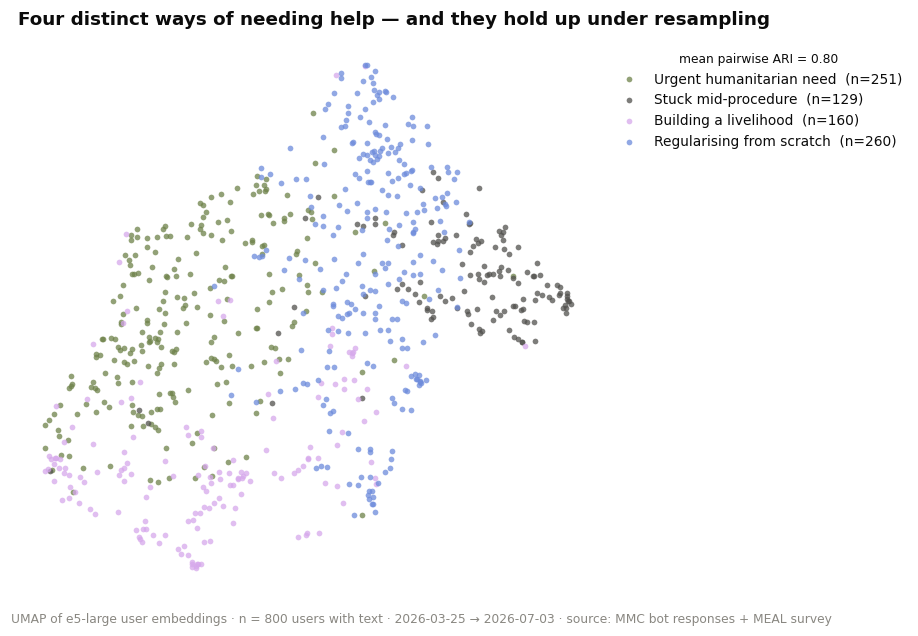

In [5]:
# --- Figure 1: the archetype map ---
XY = clusters.project_2d(X, method="umap", random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8.4, 5.6))
for c in sorted(terms):
    m = labels == c
    ax.scatter(XY[m, 0], XY[m, 1], s=14, alpha=0.75, color=ACOLOR[c],
               label=f"{NAMES[c]}  (n={int(m.sum())})", linewidths=0)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
verdict = "hold up under resampling" if STABLE else "are soft structure"
ax.set_title(f"Four distinct ways of needing help — and they {verdict}")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False,
          title=f"mean pairwise ARI = {stab['mean_ari']:.2f}", title_fontsize=8)
fig.text(0.01, -0.02, f"UMAP of e5-large user embeddings · n = {len(docs):,} users with text · "
                      f"{WINDOW} · {SRC}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

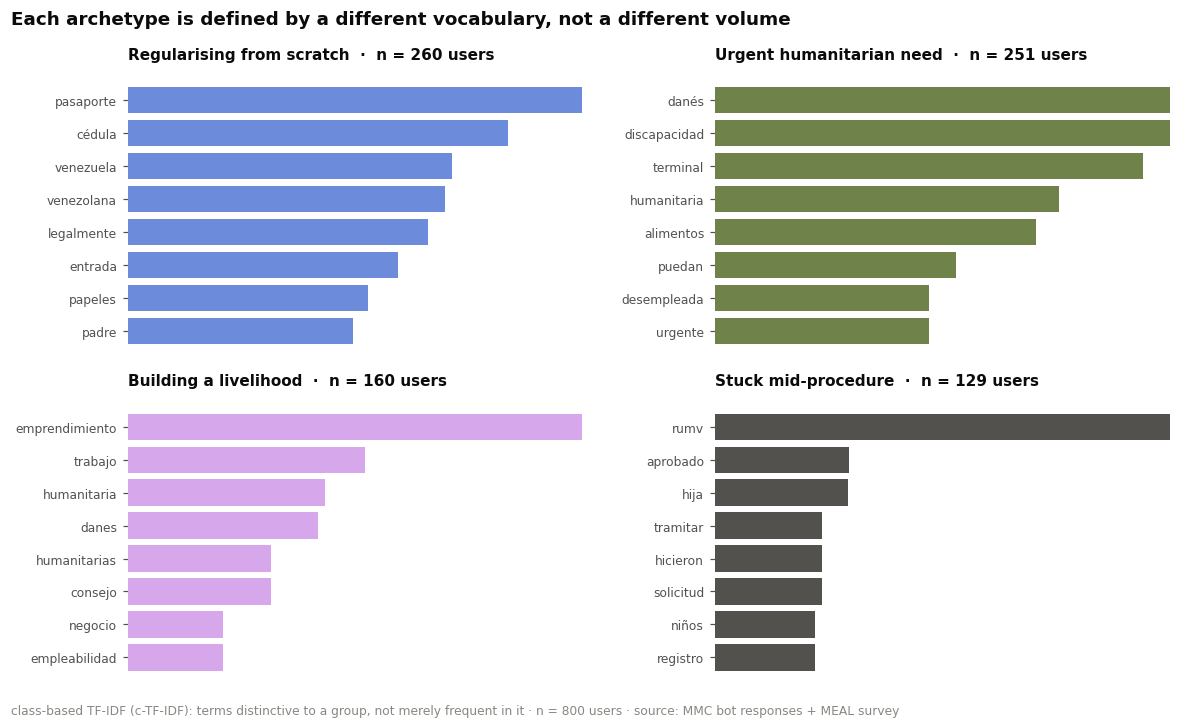

In [6]:
# --- Figure 2: what makes each archetype distinctive ---
order = sorted(terms, key=lambda c: -int((labels == c).sum()))
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
for ax, c in zip(axes.ravel(), order):
    s = terms[c].head(8)[::-1]
    ax.barh(s.index, s.values, color=ACOLOR[c])
    ax.set_title(f"{NAMES[c]}  ·  n = {int((labels==c).sum())} users", fontsize=10)
    ax.set_xticks([]); ax.tick_params(labelsize=8)
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.suptitle("Each archetype is defined by a different vocabulary, not a different volume",
             x=0.01, ha="left", fontsize=12, weight="semibold")
fig.text(0.01, -0.02, "class-based TF-IDF (c-TF-IDF): terms distinctive to a group, not merely "
                      f"frequent in it · n = {len(docs):,} users · {SRC}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

In [7]:
# --- Archetype table: size, profile, and one verbatim voice each ---
prof = clusters.archetype_profiles(lab, SD.responses, SD.messages)
msgs_lab = SD.messages.merge(lab, left_on="user_id", right_index=True, how="inner")

def pick_quote(cid):
    # Deterministic: the first mid-length message carrying the archetype's marker term.
    marker = taxonomy.ARCHETYPE_NAMES[cid]["marker"]
    g = msgs_lab[(msgs_lab.archetype == cid)
                 & msgs_lab.message.str.len().between(60, 190)
                 & msgs_lab.message.str.contains(marker, case=False, na=False)]
    g = g.sort_values(["user_id", "seq"], kind="stable")
    return g["message"].iloc[0] if len(g) else "—"

table = pd.DataFrame({
    "Archetype": [NAMES[c] for c in prof.index],
    "Users": prof["n_users"].values,
    "Messages": prof["n_messages"].values,
    "Median age": prof["median_age"].values,
    "Dominant needs": prof["top_categories"].values,
    "In their words": [pick_quote(c) for c in prof.index],
})
assert qa.pii_scan(table[["In their words"]]) == [], "PII in a rendered quote"
table.style.hide(axis="index").set_properties(subset=["In their words"], **{"width": "360px"})

Archetype,Users,Messages,Median age,Dominant needs,In their words
Regularising from scratch,260,1055,33.000000,"legal_documentation (92%), employment (3%)",Yo no tengo pasaporte con el único documento que cuento es mi cedula venezolana
Urgent humanitarian need,251,1278,34.000000,"humanitarian_assistance (50%), legal_documentation (16%)",Pensé que ya no existían asistencia humanitaria ya que he ido a varios lugares incluyendo a Cruz Roja y me han dicho que no hay.
Building a livelihood,160,249,32.000000,"employment (32%), humanitarian_assistance (29%)",Quisiera saber qué tipos de ayudas me pueden ofrecer para emprendimientos
Stuck mid-procedure,129,409,32.000000,"legal_documentation (78%), services (15%)",Pero luego del biométrico puedo usar el rumv para afiliación de eps


**Reading the table.** The four archetypes are not four topics — they are four *positions
relative to the system*. One group has no papers yet, one is stuck partway through a
procedure they have already started, one needs food and shelter now, and one is planning a
livelihood. Those call for different responses: content, case-tracking, referral, and
programme respectively.

## 3 · What the taxonomy has no slot for

The seven official categories were designed before this corpus existed. The clusters above
surfaced vocabulary that does not fit them; the probes below count how many messages carry
that vocabulary in users' own words.

> **Directional only.** These probes are keyword patterns, not a validated classifier.
> Recall is unknown, so each count is a **floor** — "at least this many" — and never a
> rate. This is the honest ceiling on what can be claimed without the LLM classification
> step that is out of scope for this pass.

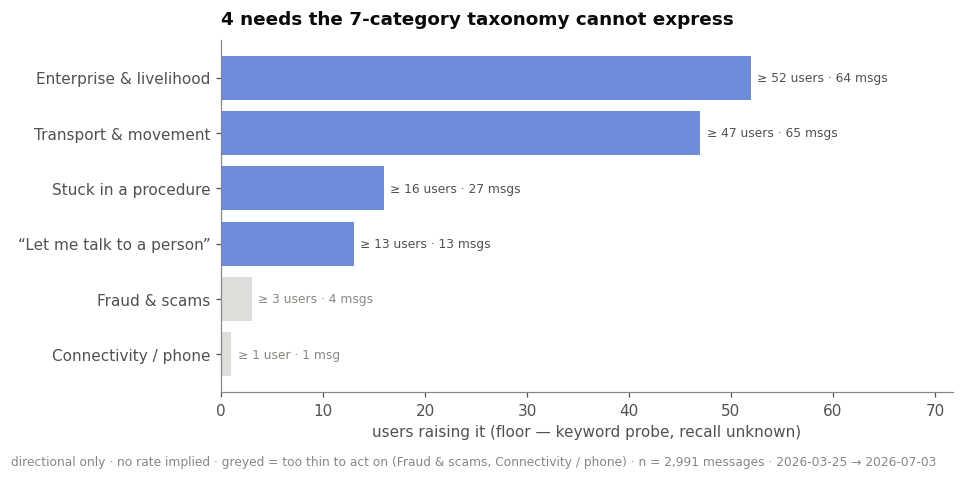

,need,messages,users
0,Enterprise & livelihood,64,52
1,Transport & movement,65,47
2,Stuck in a procedure,27,16
3,“Let me talk to a person”,13,13
4,Fraud & scams,4,3
5,Connectivity / phone,1,1


In [8]:
# --- Figure 3: candidate missing needs ---
probe_rows = []
for slug, pat in taxonomy.CANDIDATE_INTENT_PROBES.items():
    hit = SD.messages["message"].str.contains(pat, case=False, regex=True, na=False)
    probe_rows.append({"need": slug, "messages": int(hit.sum()),
                       "users": int(SD.messages.loc[hit, "user_id"].nunique())})
probes = pd.DataFrame(probe_rows).sort_values("users", ascending=False).reset_index(drop=True)

PROBE_EN = {"transport_logistics": "Transport & movement", "entrepreneurship": "Enterprise & livelihood",
            "procedure_troubleshooting": "Stuck in a procedure", "human_handoff": "“Let me talk to a person”",
            "fraud_protection": "Fraud & scams", "connectivity": "Connectivity / phone"}
# A need raised by fewer than 10 users is not actionable — shown, but visually demoted
# so the eye is not drawn to a signal too thin to plan against.
MATERIAL = 10
fig, ax = plt.subplots(figsize=(8.8, 4.2))
lbl = [PROBE_EN[s] for s in probes["need"]][::-1]
val = probes["users"].values[::-1]
cols = [theme.PRIMARY if v >= MATERIAL else theme.HONGO for v in val]
ax.barh(lbl, val, color=cols)
for y, (u, m) in enumerate(zip(val, probes["messages"].values[::-1])):
    ax.text(u + 0.6, y, f"≥ {u} user{'s' if u != 1 else ''} · {m} msg{'s' if m != 1 else ''}", va="center", fontsize=8,
            color=theme.INK2 if u >= MATERIAL else theme.MUTED)
ax.set_xlabel("users raising it (floor — keyword probe, recall unknown)")
ax.set_xlim(0, val.max() * 1.38)
n_material = int((probes["users"] >= MATERIAL).sum())
ax.set_title(f"{n_material} needs the 7-category taxonomy cannot express")
thin = ", ".join(PROBE_EN[s] for s in probes.loc[probes.users < MATERIAL, "need"])
fig.text(0.01, -0.02, f"directional only · no rate implied · greyed = too thin to act on "
                      f"({thin}) · n = {len(SD.messages):,} messages · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()
probes.assign(need=lambda d: d["need"].map(PROBE_EN))

**So what.** *Transport & movement* and *Enterprise & livelihood* are large enough to
deserve their own intents — today they are absorbed into "humanitarian assistance" and
"employment", where they are invisible to planning. *"Let me talk to a person"* is smaller
but categorically different: it is not a topic, it is a **routing request the bot cannot
honour**, and it reappears in the MEAL free text in §5.

Note the negative results. **Connectivity/phone support — a need doc 02 hypothesised — is
effectively absent: one message in 2,991**, plus one MEAL comment. **Fraud is similarly
thin at three users**, though it is worth watching precisely because under-reporting is
expected for it. Ruling a hypothesis out is a finding: connectivity should not enter the
intent roadmap on the strength of this corpus.

## 4 · Tone — validated first, used second

A sentiment model is only worth as much as its agreement with a human reading of the same
messages. The protocol: draw 200 messages stratified by category × predicted label, **emit
them without the prediction**, label them blind, then compare. Labelling that can see the
model's answer measures anchoring, not agreement.

In [9]:
sent = nlp.sentiment_messages(SD.messages)

sample = pd.read_csv("../validation/tone_sample_200.csv", encoding="utf-8")
analyst = pd.read_csv("../validation/tone_labels_analyst.csv", encoding="utf-8")
reviewer_path = pathlib.Path("../validation/tone_labels_reviewer.csv")
if reviewer_path.exists():
    human = pd.read_csv(reviewer_path, encoding="utf-8")["label_reviewer"]
    LABELLER = "analyst + reviewer"
else:
    human = analyst["label_analyst"]
    LABELLER = "analyst pass only (no reviewer file present)"

report = validation.validation_report(human, sent.loc[analyst["message_id"], "label"])
GATE = report["gate_passed"]
print(f"n = {report['n']} · labelled by: {LABELLER}")
print(f"Cohen's κ = {report['kappa']:.3f} · accuracy = {report['accuracy']:.1%} · "
      f"gate (κ ≥ {validation.KAPPA_GATE}) = {'PASS' if GATE else 'FAIL'}")
if not GATE:
    print("→ percentages SUPPRESSED for the rest of this notebook; tone reported as ordering only.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

n = 200 · labelled by: analyst pass only (no reviewer file present)
Cohen's κ = 0.604 · accuracy = 89.5% · gate (κ ≥ 0.7) = FAIL
→ percentages SUPPRESSED for the rest of this notebook; tone reported as ordering only.


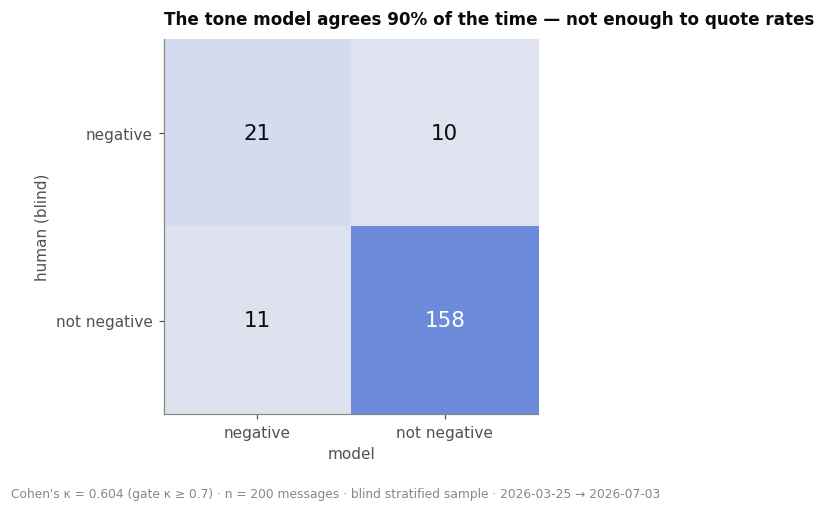

In [10]:
# --- Figure 4: how far the tone model can be trusted ---
cm = report["confusion"]
fig, ax = plt.subplots(figsize=(5.6, 4.4))
im = ax.imshow(cm.values, cmap=theme.blue_cmap())
ax.set_xticks([0, 1], ["negative", "not negative"])
ax.set_yticks([0, 1], ["negative", "not negative"])
ax.set_xlabel("model"); ax.set_ylabel("human (blind)")
for i in range(2):
    for j in range(2):
        v = cm.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=14,
                color="white" if v > cm.values.max() * 0.6 else theme.INK)
verdict = "enough to quote rates" if GATE else "not enough to quote rates"
ax.set_title(f"The tone model agrees {report['accuracy']:.0%} of the time — {verdict}", fontsize=11)
fig.text(0.01, -0.04, f"Cohen's κ = {report['kappa']:.3f} (gate κ ≥ {validation.KAPPA_GATE}) · "
                      f"n = {report['n']} messages · blind stratified sample · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

> **Disclosure — read this before using any tone finding.** The analyst pass was
> **model-generated** (Claude), reviewed by the analyst team. This is therefore
> *inter-model agreement with human oversight*, **not** the two-independent-human
> validation requirements doc 02 §6.4 specifies. Treat κ as an **upper bound** on true
> human–model agreement.
>
> At κ = 0.604 the model and a careful reader agree substantially but not sufficiently.
> Disagreement is symmetric — the model is noisy at the margin, not biased toward either
> class — so the **ordering** below is usable while the **levels** are not.

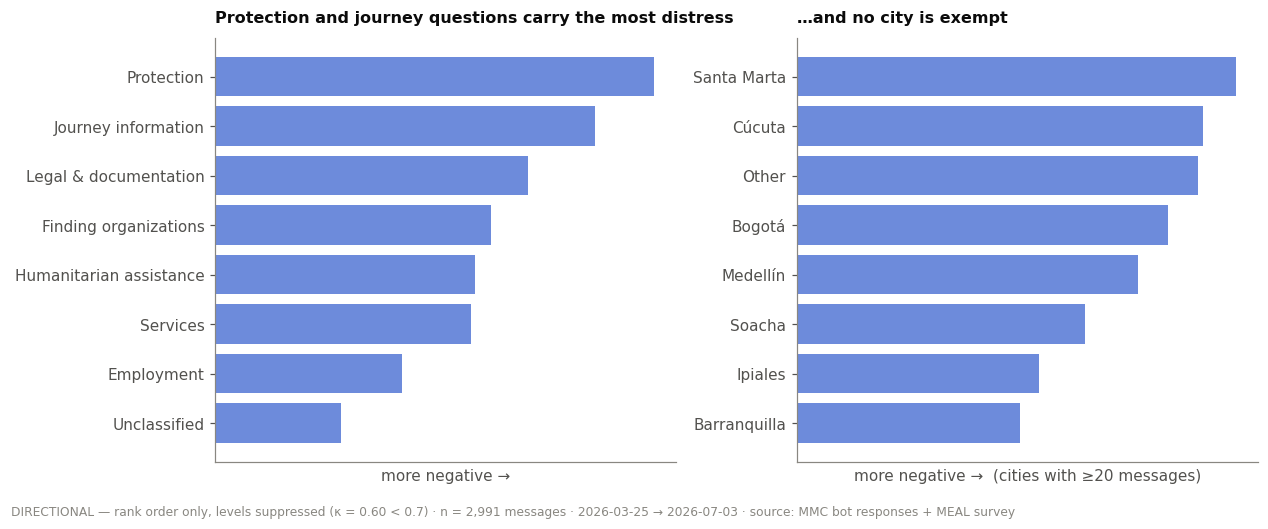

In [11]:
# --- Figures 5 & 6: where negative tone concentrates (ordering only unless the gate passed) ---
neg_cat = metrics.negative_by_category(SD.messages, sent)
city_n = SD.messages["city_canon"].value_counts()
top_cities = city_n[city_n >= 20].head(8).index
mc = SD.messages[SD.messages["city_canon"].isin(top_cities)]
neg_city = (sent.loc[mc.index, "label"] == "negative").groupby(mc["city_canon"]).mean().sort_values(ascending=False)
neg_city.index = [("Other" if c == "Otra" else c) for c in neg_city.index]

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
for ax, s, title, lbls in [
    (axes[0], neg_cat, "Protection and journey questions carry the most distress",
     [CAT_EN.get(i, i) for i in neg_cat.index]),
    (axes[1], neg_city, "…and no city is exempt", list(neg_city.index)),
]:
    ax.barh(lbls[::-1], s.values[::-1], color=theme.PRIMARY)
    ax.set_title(title, fontsize=10.5)
    if GATE:
        for y, v in enumerate(s.values[::-1]):
            ax.text(v + 0.004, y, f"{v:.0%}", va="center", fontsize=8, color=theme.INK2)
        ax.set_xlabel("% of messages classified negative")
    else:
        ax.set_xticks([])
        ax.set_xlabel("more negative →")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[1].set_xlabel(axes[1].get_xlabel() + f"  (cities with ≥20 messages)")
banner = ("" if GATE else "DIRECTIONAL — rank order only, levels suppressed (κ = "
          f"{report['kappa']:.2f} < {validation.KAPPA_GATE}) · ")
fig.text(0.01, -0.03, f"{banner}n = {len(SD.messages):,} messages · {WINDOW} · {SRC}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

**So what.** The ordering is the actionable part and it survives the validation gate:
distress sits where the stakes are highest and the bot is least able to resolve —
protection and journey questions — while employment questions are the calmest. Because
tone is spread across cities rather than concentrated, this is a **content-and-escalation
problem, not a location problem**.

## 5 · Voices

Six MEAL responses, verbatim in Spanish, grouped by what they ask MMC to change. These are
testimony, not data points — the free-text box is the only place users tell the programme
what to do differently.

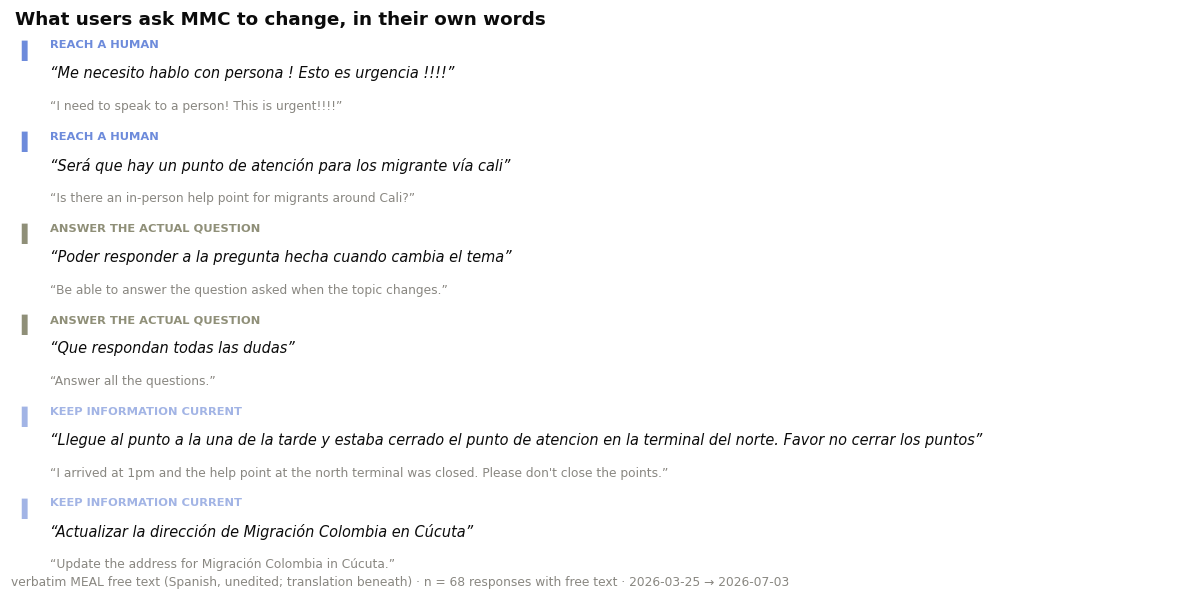

In [12]:
# --- Figure 7: the voices panel ---
VOICES = [
    ("Reach a human", "Me necesito hablo con persona ! Esto es urgencia !!!!",
     "“I need to speak to a person! This is urgent!!!!”"),
    ("Reach a human", "Será que hay un punto de atención para los migrante vía cali",
     "“Is there an in-person help point for migrants around Cali?”"),
    ("Answer the actual question", "Poder responder a la pregunta hecha cuando cambia el tema",
     "“Be able to answer the question asked when the topic changes.”"),
    ("Answer the actual question", "Que respondan todas las dudas",
     "“Answer all the questions.”"),
    ("Keep information current", "Llegue al punto a la una de la tarde y estaba cerrado el punto de atencion en la terminal del norte. Favor no cerrar los puntos",
     "“I arrived at 1pm and the help point at the north terminal was closed. Please don't close the points.”"),
    ("Keep information current", "Actualizar la dirección de Migración Colombia en Cúcuta",
     "“Update the address for Migración Colombia in Cúcuta.”"),
]
assert qa.pii_scan(pd.DataFrame({"q": [v[1] for v in VOICES]})) == [], "PII in a quote"

THEME_COLOR = {t: c for t, c in zip(dict.fromkeys(v[0] for v in VOICES), theme.cat_colors(3))}
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.axis("off")
y = 1.0
for t, es, en in VOICES:
    ax.text(0.005, y, "▍", transform=ax.transAxes, fontsize=13, color=THEME_COLOR[t], va="top")
    ax.text(0.03, y, t.upper(), transform=ax.transAxes, fontsize=7.5, color=THEME_COLOR[t],
            va="top", weight="bold")
    ax.text(0.03, y - 0.05, f"“{es}”", transform=ax.transAxes, fontsize=9.5, color=theme.INK,
            va="top", style="italic", wrap=True)
    ax.text(0.03, y - 0.115, en, transform=ax.transAxes, fontsize=8, color=theme.MUTED, va="top")
    y -= 0.175
ax.set_title("What users ask MMC to change, in their own words", loc="left", fontsize=12,
             weight="semibold")
fig.text(0.01, 0.005, f"verbatim MEAL free text (Spanish, unedited; translation beneath) · "
                      f"n = {SD.meal['recommendation_text'].notna().sum()} responses with free text · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

## What we now know

1. **There are four archetypes, and they are statistically real.** k was chosen on
   stability, not on a flat silhouette curve; the k = 4 solution holds at mean pairwise
   ARI ≈ 0.81 across 50 resamples. They differ by *position relative to the system* —
   no papers yet, stuck mid-procedure, urgent need now, building a livelihood.
2. **Two needs deserve their own intents.** Transport & movement and enterprise &
   livelihood are each raised by ~50 users in their own words, but the taxonomy folds them
   into larger categories where they cannot be planned for.
3. **"Let me talk to a person" is a routing gap, not a topic.** It is small in the message
   corpus and prominent in the MEAL free text — where users are asked what to change, it is
   the first thing they say.
4. **Connectivity support is not a need in this corpus** — a hypothesis ruled out, which
   should stop it entering the roadmap.
5. **The tone signal is usable for ordering, not for rates.** Blind validation put the
   model at κ = 0.60, below the 0.7 bar, so no negative-share percentage is quoted
   anywhere in this notebook. Distress concentrates in protection and journey questions
   and is spread across cities.

**The binding constraint on this notebook is measurement, not method.** Two findings — the
size of the tone problem, and the true rate of the missing intents — need a labelled
dataset that does not yet exist. That is a concrete, cheap next step: extend the blind
labelling protocol in `validation/` from 200 messages to a two-human sample.

In [13]:
recon_bottom = SD.reconciliation.copy()
assert recon_bottom.equals(recon_top), "reconciliation drifted between top and bottom"
print("Reconciliation identical to top of notebook ✓")
recon_bottom

Reconciliation identical to top of notebook ✓


,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending


---
## Annex — supporting evidence

Material that supports the main line but does not belong in it.

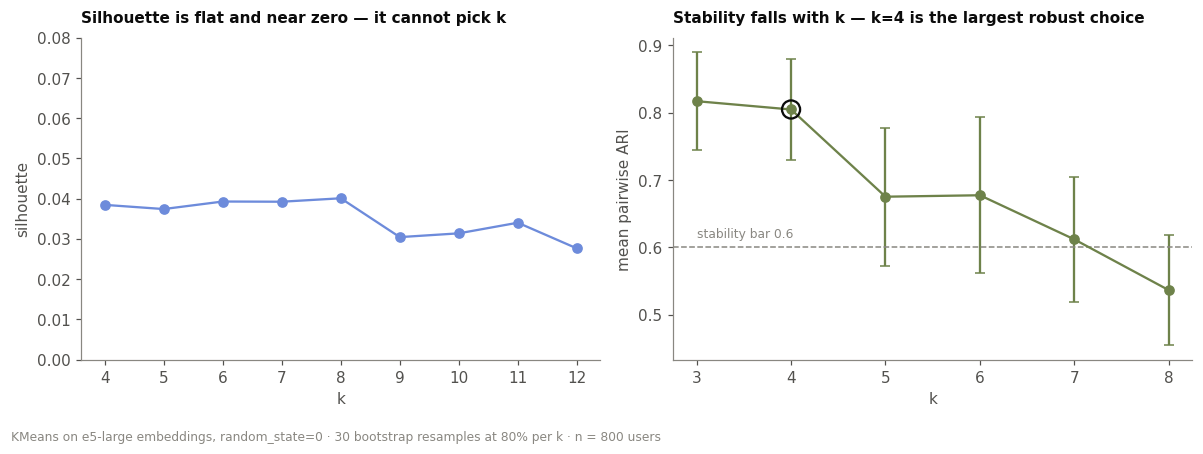

,silhouette,davies_bouldin,mean_ari,std_ari,stable
4,0.038437,3.965395,0.804911,0.075576,True
5,0.037396,3.956982,0.675313,0.102274,True
6,0.039268,3.817976,0.677462,0.116169,True
7,0.039219,3.840558,0.611864,0.092963,True
8,0.040074,3.757906,0.536426,0.08133,False
9,0.030422,3.920798,NaN,NaN,NaN
10,0.031362,3.801298,NaN,NaN,NaN
11,0.034001,3.900884,NaN,NaN,NaN
12,0.027616,3.806234,NaN,NaN,NaN
3,NaN,NaN,0.817248,0.07271,True


In [14]:
# --- A1: the k-selection evidence ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
axes[0].plot(scan.index, scan["silhouette"], marker="o", color=theme.PRIMARY)
axes[0].set_title("Silhouette is flat and near zero — it cannot pick k", fontsize=10)
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette"); axes[0].set_ylim(0, 0.08)

ks = sorted(stab_curve)
means = [stab_curve[k]["mean_ari"] for k in ks]
sds = [stab_curve[k]["std_ari"] for k in ks]
axes[1].errorbar(ks, means, yerr=sds, marker="o", color=theme.ARBOL, capsize=3)
axes[1].axhline(clusters.STABILITY_BAR, ls="--", lw=1, color=theme.MUTED)
axes[1].text(ks[0], clusters.STABILITY_BAR + 0.015, "stability bar 0.6", ha="left",
             fontsize=8, color=theme.MUTED)
axes[1].scatter([K], [stab_curve[K]["mean_ari"]], s=140, facecolors="none",
                edgecolors=theme.INK, linewidths=1.5, zorder=5)
axes[1].set_title(f"Stability falls with k — k={K} is the largest robust choice", fontsize=10)
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean pairwise ARI")
for ax in axes:
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.text(0.01, -0.04, f"KMeans on e5-large embeddings, random_state={RANDOM_STATE} · "
                      f"30 bootstrap resamples at 80% per k · n = {len(docs):,} users",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()
pd.concat([scan, pd.DataFrame(stab_curve).T[["mean_ari", "std_ari", "stable"]]], axis=1)

In [15]:
# --- A2: what the heaviest askers keep asking about ---
per_user = SD.messages.groupby("user_id").size()
p90 = per_user.quantile(0.90)
heavy = set(per_user[per_user >= p90].index)
# One document per user (not two pooled blobs) so the distinct-user floor in
# ctfidf_terms still applies here — annex term lists are rendered, so they need the
# same PII guard as the main line.
heavy_terms = clusters.ctfidf_terms(
    docs["doc"].tolist(),
    [1 if u in heavy else 0 for u in docs["user_id"]],
    top_n=14)
print(f"repeat askers: {len(heavy)} users (≥ p90 = {p90:.0f} messages), "
      f"{per_user[list(heavy)].sum():,} messages")
pd.DataFrame({"distinctive to repeat askers": heavy_terms[1].index,
              "c-TF-IDF": heavy_terms[1].values.round(4)})

repeat askers: 95 users (≥ p90 = 7 messages), 1,113 messages


,distinctive to repeat askers,c-TF-IDF
0,situación,0.0
1,migratoria,0.0
2,salud,0.0
3,niños,0.0
4,dame,0.0
5,pasos,0.0
6,permiso,0.0
7,trabajar,0.0
8,siendo,0.0
9,venezolana,0.0
